# 14. HistGradientBoosting из scikit-learn: бустинг без дополнительных библиотек

| | |
|---|---|
| **Уровень** | 3 из 4 — средние данные: полный цикл и типовые случаи (`3_medium`) |
| **Скрипт-источник** | [`14_sklearn_hist_gbm.py`](../14_sklearn_hist_gbm.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 15 с |

**Цель.** Освоить встроенный в scikit-learn гистограммный бустинг — он есть везде, где есть sklearn.

### Чему вы научитесь

- Пропуски и категории «из коробки» (`categorical_features="from_dtype"`)
- Автоматическая ранняя остановка (`early_stopping="auto"` включается от 10 000 объектов)
- Монотонные ограничения (`monotonic_cst`)
- Место в `Pipeline` и `cross_validate`
- Сравнение со старым `GradientBoostingRegressor`

### Данные

`_data.make_houses` — 20 000 квартир; цель — `log(цены)`.

### План

1. **Этап 1.** Данные
2. **Этап 2.** По умолчанию: категории по типу столбца, пропуски как есть
3. **Этап 3.** Больше итераций и меньший темп, ранняя остановка явно
4. **Этап 4.** Ограничения: цена не убывает с площадью и не растёт с расстоянием до центра
5. **Этап 5.** cross_validate: 5 фолдов — модель ведёт себя как любой оценщик sklearn
6. **Этап 6.** Старый GradientBoostingRegressor: без гистограмм, без категорий и пропусков

> Ноутбук собран из `examples/3_medium/14_sklearn_hist_gbm.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example
from _data import make_houses

ex = Example(EXAMPLES / "3_medium/14_sklearn_hist_gbm.py", title="14. HistGradientBoosting из scikit-learn",
             goal="освоить встроенный в sklearn гистограммный бустинг")

import matplotlib.pyplot as plt
import numpy as np
from gbcourse.style import ROLE
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_validate

## Этап 1. Данные

In [2]:
X, price = make_houses(ex.size(20_000, 4000))
y = np.log(price)
ex.describe(X, y, target="log(цена)", source="examples/_data.py → make_houses")
n = len(y)
perm = np.random.default_rng(0).permutation(n)
tr, te = perm[: int(0.8 * n)], perm[int(0.8 * n):]
rel = lambda p: float(np.mean(np.abs(price[te] - np.exp(p)) / price[te]))

   Источник: examples/_data.py → make_houses
   Объектов: 20 000   признаков: 10   память: 1.26 МБ
   Типы признаков: int64 × 5, float64 × 3, category × 2
   Пропуски: кухня 4.9%
   Цель «log(цена)»: среднее 2.063, σ 0.473, мин -0.109, макс 3.552
   Первые строки:


,площадь,комнаты,этаж,этажность,год,до_центра_км,район,парковка,ремонт,кухня,[log(цена)]
0,92.0,4,17,17,2001,6.12,район_06,1,евро,13.7,2.579686
1,62.2,2,6,17,1973,5.29,район_01,0,косметический,10.5,2.263012
2,69.2,3,9,12,1987,7.71,район_00,0,косметический,14.5,2.372391


## Этап 2. По умолчанию: категории по типу столбца, пропуски как есть

In [3]:
m = HistGradientBoostingRegressor(random_state=0)
with ex.timer("обучение"):
    m.fit(X.iloc[tr], y[tr])
print(f"   категориальные признаки: {[c for c, f in zip(X.columns, m.is_categorical_) if f]}")
print(f"   ранняя остановка: {m.early_stopping} → итераций {m.n_iter_} из {m.max_iter}")
print(f"   тест: относительная ошибка {rel(m.predict(X.iloc[te])):.2%}")
ex.note("early_stopping='auto' включается при n > 10 000: sklearn сам отрезает 10% на валидацию.")

   ⏱ обучение: 0.29 с
   категориальные признаки: ['район', 'ремонт']
   ранняя остановка: auto → итераций 100 из 100
   тест: относительная ошибка 7.06%


> ▸ **Вывод.** early\_stopping='auto' включается при n &gt; 10 000: sklearn сам отрезает 10% на валидацию.

## Этап 3. Больше итераций и меньший темп, ранняя остановка явно

In [4]:
m2 = HistGradientBoostingRegressor(max_iter=3000, learning_rate=0.05, max_leaf_nodes=31, early_stopping=True,
                                   validation_fraction=0.2, n_iter_no_change=50, random_state=0)
with ex.timer("обучение"):
    m2.fit(X.iloc[tr], y[tr])
print(f"   итераций {m2.n_iter_}; тест: относительная ошибка {rel(m2.predict(X.iloc[te])):.2%}")

   ⏱ обучение: 1.04 с
   итераций 481; тест: относительная ошибка 6.96%


## Этап 4. Ограничения: цена не убывает с площадью и не растёт с расстоянием до центра

   тест: относительная ошибка 7.10%
   квартир, у которых прогноз где-то падает с ростом площади: без ограничений 32%, с ограничением 0%


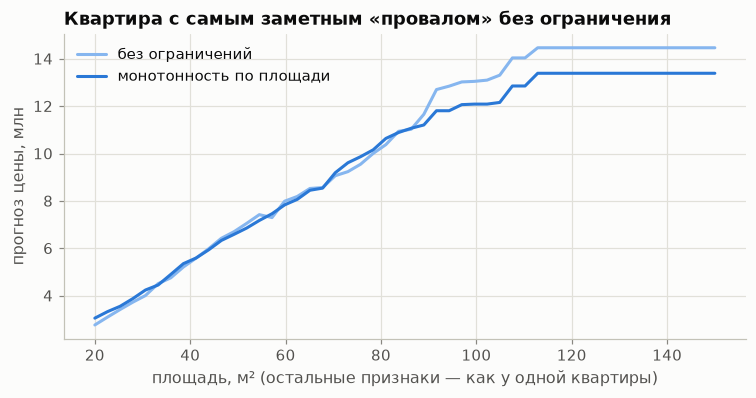

> ▸ **Вывод.** Даже на 16 000 квартир у 32% из них прогноз где-то падает с ростом площади — модель подгоняет шум. С ограничением таких квартир нет, и это гарантия для любых входов, а не только проверенных. Истинная зависимость здесь монотонна, поэтому по качеству ограничение почти ничего не стоит.

In [5]:
mono = [1 if c == "площадь" else -1 if c == "до_центра_км" else 0 for c in X.columns]
m3 = HistGradientBoostingRegressor(max_iter=3000, learning_rate=0.05, early_stopping=True, validation_fraction=0.2,
                                   n_iter_no_change=50, monotonic_cst=mono, random_state=0).fit(X.iloc[tr], y[tr])
area = np.linspace(20, 150, 50)


def worst_dip(model, n_obj=200):
    """Для 200 квартир теста меняем только площадь; возвращаем долю квартир с «провалом» и самую глубокую."""
    dips = []
    for i in te[:n_obj]:
        g = X.iloc[[i] * len(area)].copy()
        g["площадь"] = area
        dips.append((-np.diff(model.predict(g))).max())      # > 0: прогноз где-то падает с ростом площади
    dips = np.array(dips)
    return float(np.mean(dips > 1e-12)), te[int(np.argmax(dips))]


share_free, worst = worst_dip(m2)
share_mono, _ = worst_dip(m3)
print(f"   тест: относительная ошибка {rel(m3.predict(X.iloc[te])):.2%}")
print(f"   квартир, у которых прогноз где-то падает с ростом площади: без ограничений {share_free:.0%}, с ограничением {share_mono:.0%}")
assert share_mono == 0
grid = X.iloc[[worst] * len(area)].copy()
grid["площадь"] = area
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(area, np.exp(m2.predict(grid)), color=ROLE["model_prev"], lw=2, label="без ограничений")
ax.plot(area, np.exp(m3.predict(grid)), color=ROLE["model"], lw=2, label="монотонность по площади")
ax.set(xlabel="площадь, м² (остальные признаки — как у одной квартиры)", ylabel="прогноз цены, млн",
       title="Квартира с самым заметным «провалом» без ограничения")
ax.legend()
ex.finish(fig, "14_monotonic")
ex.note(f"""Даже на 16 000 квартир у {share_free:.0%} из них прогноз где-то падает с ростом площади — модель подгоняет шум.
С ограничением таких квартир нет, и это гарантия для любых входов, а не только проверенных. Истинная зависимость
здесь монотонна, поэтому по качеству ограничение почти ничего не стоит.""")

## Этап 5. cross_validate: 5 фолдов — модель ведёт себя как любой оценщик sklearn

In [6]:
cv = cross_validate(HistGradientBoostingRegressor(random_state=0), X, y, cv=KFold(5, shuffle=True, random_state=0),
                    scoring="neg_root_mean_squared_error", return_train_score=True)
print(f"   RMSE log-цены: обучение {-cv['train_score'].mean():.4f}, проверка {-cv['test_score'].mean():.4f} ± {cv['test_score'].std():.4f}; "
      f"время на фолд {cv['fit_time'].mean():.2f} с")

   RMSE log-цены: обучение 0.0774, проверка 0.0889 ± 0.0012; время на фолд 0.26 с


## Этап 6. Старый GradientBoostingRegressor: без гистограмм, без категорий и пропусков

In [7]:
Xn = X.assign(район=X["район"].cat.codes, ремонт=X["ремонт"].cat.codes, кухня=X["кухня"].fillna(X["кухня"].median()))
with ex.timer("GradientBoostingRegressor, 300 деревьев"):
    old = GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=0).fit(Xn.iloc[tr], y[tr])
print(f"   тест: относительная ошибка {rel(old.predict(Xn.iloc[te])):.2%}")
ex.note("Для данных больше нескольких тысяч строк выбирайте HistGradientBoosting: он в разы быстрее и понимает категории и пропуски.")
ex.done()

   ⏱ GradientBoostingRegressor, 300 деревьев: 6.61 с
   тест: относительная ошибка 7.05%


> ▸ **Вывод.** Для данных больше нескольких тысяч строк выбирайте HistGradientBoosting: он в разы быстрее и понимает категории и пропуски.

Готово за 13.4 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Отключите категории (`categorical_features=None`) — сколько теряет модель?
2. Задайте `interaction_cst` и проверьте, как меняется ошибка.
3. Сравните с LightGBM при одинаковых числе листьев, темпе и числе итераций.

## Что дальше

- **Теория в курсе:** [8.3 «Поиск разбиений»](../../../lessons/lesson_8_3/README.md), [12.3 «PDP, ICE, монотонность»](../../../lessons/lesson_12_3/README.md).
- **Предыдущий пример:** [13. CatBoost от начала до конца: цены квартир, 20 000 объектов](13_catboost_complete.ipynb)
- **Следующий пример:** [15. Категории с тысячей значений: пять способов подать их бустингу](15_categorical_encodings.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)